# Churn Model — Local Iteration Notebook

Use this notebook to explore features, tune model logic, and validate changes before opening a PR to `projects/modeling/` or `projects/ml-common/`.

**Prerequisites**
```bash
# one-time: authenticate with GCP
gcloud auth application-default login

# install modeling and its ml-common dependency into a local venv
uv sync --package modeling --extra dev
```

No Dockerfile, no KFP pipeline, no orchestration. Everything here calls the same `modeling` and `ml_common` functions the pipeline runs in production.

In [1]:
# ── Configuration ────────────────────────────────────────────────────────────
BQ_TABLE      = "features.customer_features"
SNAPSHOT_DATE = None                  # set to a specific "YYYY-MM-DD" partition, or None to use the latest
SAMPLE_LIMIT  = 5_000                # keep small for fast local iteration

In [2]:
import google.auth
import matplotlib.pyplot as plt
import shap
from google.cloud import bigquery
from ml_common.evaluate import compute_metrics, select_threshold
from ml_common.preprocess import feature_names, prepare_features
from modeling import config
from modeling.hpo import run_hpo
from modeling.train import train_model

# picked up from the active `gcloud auth application-default login` / `gcloud config set project` context
_, GCP_PROJECT = google.auth.default()
print(f"modeling / ml_common imports OK — using GCP project: {GCP_PROJECT}")

.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


modeling / ml_common imports OK — using GCP project: <your-gcp-project>


## 1. Load data from BigQuery

Pulls a sample from the feature table. In production the pipeline uses the full snapshot; here we cap at `SAMPLE_LIMIT` rows for speed.

In [3]:
bq = bigquery.Client(project=GCP_PROJECT)

snapshot_date = SNAPSHOT_DATE
if snapshot_date is None:
    snapshot_date = bq.query(f"""
        SELECT MAX(snapshot_date) AS latest
        FROM `{GCP_PROJECT}.{BQ_TABLE}`
    """).to_dataframe()["latest"].iloc[0].strftime("%Y-%m-%d")
    print(f"No SNAPSHOT_DATE set — using latest available partition: {snapshot_date}")

df = bq.query(f"""
    SELECT * EXCEPT (feature_computed_at, latest_event_ts)
    FROM `{GCP_PROJECT}.{BQ_TABLE}`
    WHERE snapshot_date = '{snapshot_date}'
    LIMIT {SAMPLE_LIMIT}
""").to_dataframe()

print(f"Loaded {len(df):,} rows × {df.shape[1]} columns")
df.head()

No SNAPSHOT_DATE set — using latest available partition: 2026-06-29
Loaded 5,000 rows × 21 columns


,customer_id,membership_tier,region,member_since_days,contact_requests_last_30d,avg_transaction_30d,avg_transaction_90d,payment_failure_rate_30d,payment_failure_rate_90d,total_payment_attempts,...,avg_engagement_30d,avg_engagement_90d,campaign_participation_rate,preferred_channel,total_events,events_last_30d,events_last_90d,renewal_count,churned,snapshot_date
0,fff9754a-e444-428a-9a09-bc8cd721276c,friend,eu-west,3311,1,27.75,27.75,0.0,0.0,4,...,NaN,NaN,1.0,phone,1,1,1,0,False,2026-06-29
1,3fa27d0b-208b-4ed5-90e7-a488c8603e9d,supporter,eu-central,2817,1,4.84,4.84,0.0,0.0,1,...,0.6863,0.6863,0.0,in_person,1,1,1,0,False,2026-06-29
2,cc02337d-7ec6-4915-a2cf-88859c06e55e,supporter,us-east,285,1,5.23,5.23,0.0,0.0,0,...,0.0679,0.0679,0.0,in_person,1,1,1,0,False,2026-06-29
3,0bfbbe38-edb1-4cd5-a507-bba0163f6d81,supporter,apac,3012,0,5.28,5.28,0.0,0.0,3,...,NaN,NaN,0.0,direct_mail,1,1,1,0,True,2026-06-29
4,149367e3-064b-4b9c-bbe3-47b34a2ea314,supporter,eu-central,3416,0,5.34,5.34,0.0,0.0,0,...,NaN,NaN,0.0,phone,1,1,1,0,False,2026-06-29


## 2. Explore

Quick sanity checks before touching model code.

In [4]:
# class balance
churn_rate = df["churned"].mean()
print(f"Churn rate: {churn_rate:.1%}  ({df['churned'].sum():,} positives / {len(df):,} total)")

# feature types
df.dtypes

Churn rate: 14.8%  (738 positives / 5,000 total)


customer_id                                  str
membership_tier                           str
region                                    str
member_since_days                       Int64
contact_requests_last_30d               Int64
avg_transaction_30d                      float64
avg_transaction_90d                      float64
payment_failure_rate_30d              float64
payment_failure_rate_90d              float64
total_payment_attempts                  Int64
days_since_last_successful_payment      Int64
avg_engagement_30d                    float64
avg_engagement_90d                    float64
campaign_participation_rate           float64
preferred_channel                         str
total_events                            Int64
events_last_30d                         Int64
events_last_90d                         Int64
renewal_count                           Int64
churned                               boolean
snapshot_date                          dbdate
dtype: object

In [5]:
# missing values
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

days_since_last_successful_payment    2597
avg_engagement_30d                    1641
avg_engagement_90d                    1641
member_since_days                      144
dtype: int64

In [6]:
# numeric feature distributions by churn label
numeric_cols = df.select_dtypes(include="number").columns.drop("churned", errors="ignore")
df.groupby("churned")[numeric_cols].median().T.rename(columns={0: "not_churned", 1: "churned"})

churned,not_churned,churned
member_since_days,1795.0,1773.0
contact_requests_last_30d,0.0,0.0
avg_transaction_30d,11.08,11.2
avg_transaction_90d,11.08,11.2
payment_failure_rate_30d,0.0,0.0
payment_failure_rate_90d,0.0,0.0
total_payment_attempts,1.0,1.0
days_since_last_successful_payment,0.0,0.0
avg_engagement_30d,0.2676,0.14035
avg_engagement_90d,0.2676,0.14035


## 3. Preprocess

`prepare_features` encodes categoricals and drops metadata columns. Edit `preprocess.py` if the feature set changes.

In [7]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=config.TEST_SIZE,
    random_state=config.RANDOM_STATE,
    stratify=df["churned"],
)

X_train, y_train = prepare_features(train_df)
X_test,  y_test  = prepare_features(test_df)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Features: {feature_names(train_df)}")

Train: (4000, 18)  |  Test: (1000, 18)
Features: ['membership_tier', 'region', 'member_since_days', 'contact_requests_last_30d', 'avg_transaction_30d', 'avg_transaction_90d', 'payment_failure_rate_30d', 'payment_failure_rate_90d', 'total_payment_attempts', 'days_since_last_successful_payment', 'avg_engagement_30d', 'avg_engagement_90d', 'campaign_participation_rate', 'preferred_channel', 'total_events', 'events_last_30d', 'events_last_90d', 'renewal_count']


## 4. Quick training run (no HPO)

Useful for fast feedback while iterating on features or preprocessing. Use manually chosen params here; run HPO in the next section when you want a proper search.

In [8]:
quick_params = {
    "max_depth": 5,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "n_estimators": 200,
}

model, feat_names, shap_importance = train_model(
    X_train, y_train,
    params=quick_params,
    fixed_params=config.XGB_FIXED_PARAMS,
    random_state=config.RANDOM_STATE,
)

print("Training complete")

Training complete


In [9]:
# evaluate on test set — select the operating threshold first, then score at it
proba = model.predict_proba(X_test)[:, 1]
threshold = select_threshold(y_test.to_numpy(), proba, config.TARGET_RECALL)
metrics = compute_metrics(y_test.to_numpy(), proba, threshold)

print(f"PR-AUC : {metrics['pr_auc']:.4f}")
print(f"ROC-AUC: {metrics['roc_auc']:.4f}")
print(f"F1     : {metrics['f1']:.4f}  (threshold={metrics['threshold']:.3f})")

PR-AUC : 0.2262
ROC-AUC: 0.6757
F1     : 0.3371  (threshold=0.213)


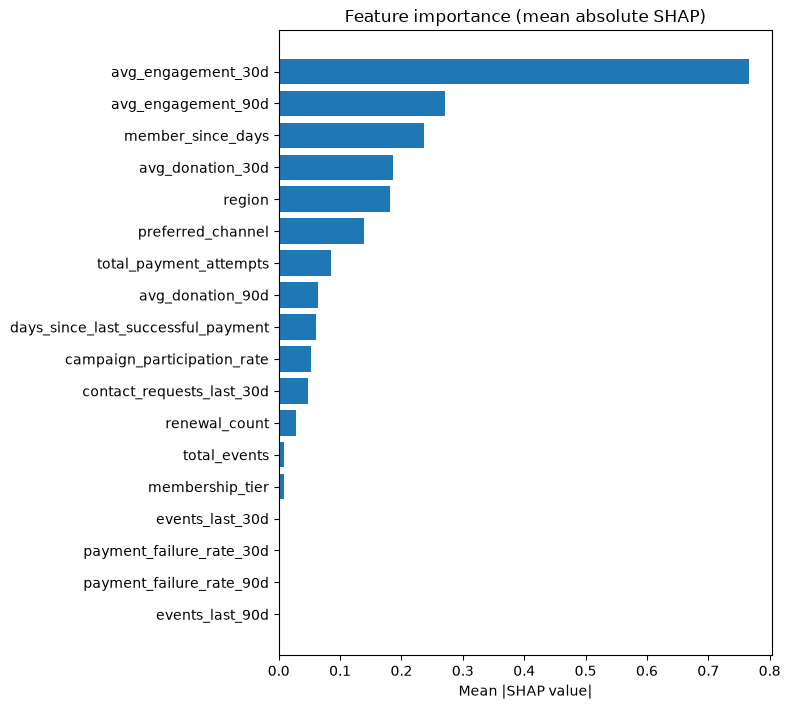

In [10]:
# SHAP feature importance
sorted_shap = sorted(shap_importance.items(), key=lambda x: x[1], reverse=True)

features, values = zip(*sorted_shap, strict=True)
plt.figure(figsize=(8, len(features) * 0.4))
plt.barh(features[::-1], values[::-1])
plt.xlabel("Mean |SHAP value|")
plt.title("Feature importance (mean absolute SHAP)")
plt.tight_layout()
plt.show()

## 5. Hyperparameter search (reduced budget for local speed)

Runs Optuna with a small trial/fold budget. When satisfied, copy `best_params` into `config.HPO_SEARCH_SPACE` or use them as a starting point for the production run.

The production pipeline runs `n_trials=config.HPO_N_TRIALS` (100) with `n_folds=config.HPO_N_FOLDS` (5) — increase here if you have time.

In [11]:
best_params = run_hpo(
    X_train, y_train,
    search_space=config.HPO_SEARCH_SPACE,
    fixed_params=config.XGB_FIXED_PARAMS,
    n_trials=15,    # small for local; production uses config.HPO_N_TRIALS
    n_folds=3,      # small for local; production uses config.HPO_N_FOLDS
    random_state=config.RANDOM_STATE,
    # no trial_callback — experiment logging is added by training-platform
)

print("Best params:", best_params)

Best params: {'max_depth': 4, 'learning_rate': 0.012184186502221764, 'subsample': 0.9330880728874675, 'colsample_bytree': 0.8005575058716043, 'n_estimators': 369}


In [12]:
# train with best HPO params and evaluate
model_hpo, feat_names_hpo, shap_importance_hpo = train_model(
    X_train, y_train,
    params=best_params,
    fixed_params=config.XGB_FIXED_PARAMS,
    random_state=config.RANDOM_STATE,
)

proba_hpo = model_hpo.predict_proba(X_test)[:, 1]
threshold_hpo = select_threshold(y_test.to_numpy(), proba_hpo, config.TARGET_RECALL)
metrics_hpo = compute_metrics(y_test.to_numpy(), proba_hpo, threshold_hpo)

print(f"PR-AUC : {metrics_hpo['pr_auc']:.4f}  (vs quick: {metrics['pr_auc']:.4f})")
print(f"ROC-AUC: {metrics_hpo['roc_auc']:.4f}  (vs quick: {metrics['roc_auc']:.4f})")
print(f"F1     : {metrics_hpo['f1']:.4f}  (vs quick: {metrics['f1']:.4f})")

PR-AUC : 0.2595  (vs quick: 0.2262)
ROC-AUC: 0.6985  (vs quick: 0.6757)
F1     : 0.3865  (vs quick: 0.3371)


## 6. Inspect SHAP in detail

The beeswarm plot shows how each feature pushes predictions toward churn (positive) or not (negative) across all samples. Useful for catching unexpected feature behaviour before shipping.

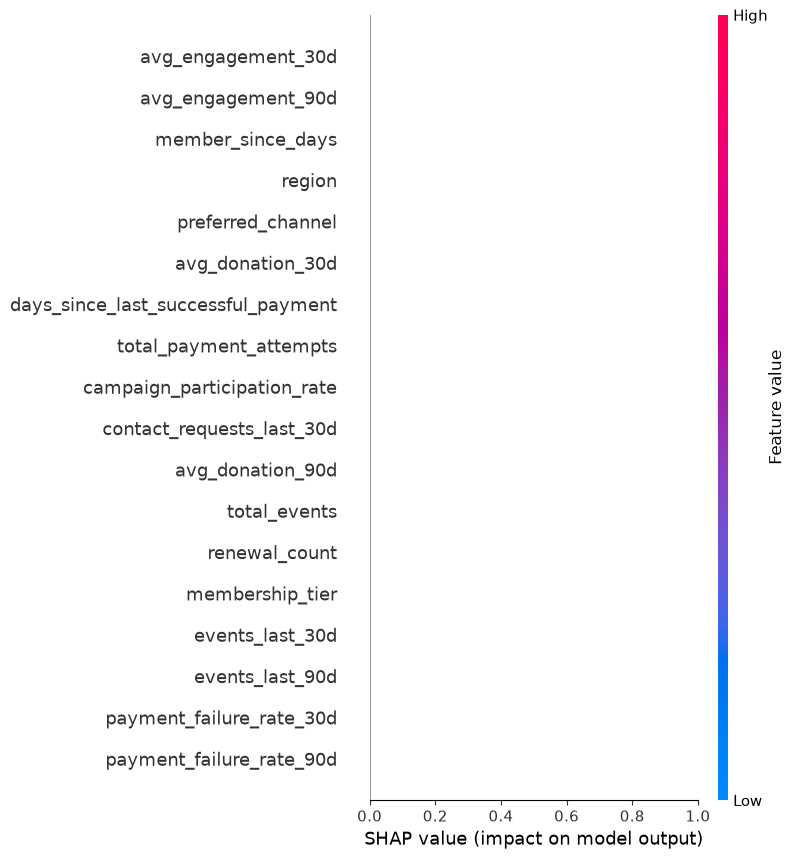

In [13]:
explainer = shap.TreeExplainer(model_hpo)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="beeswarm", show=True)

## 7. Threshold inspection

The pipeline selects the threshold that achieves `TARGET_RECALL` (currently **0.80**) with the highest possible precision. Adjust `config.TARGET_RECALL` if the business requirement changes.

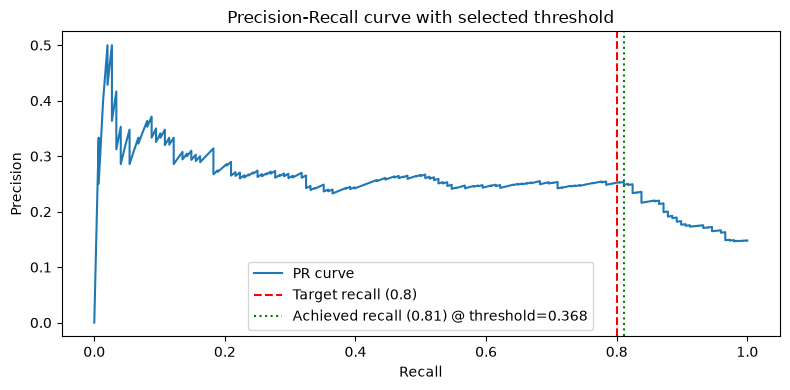

In [14]:
from sklearn.metrics import precision_recall_curve

y_np = y_test.to_numpy()
precisions, recalls, thresholds = precision_recall_curve(y_np, proba_hpo)

chosen = select_threshold(y_np, proba_hpo, config.TARGET_RECALL)
preds  = (proba_hpo >= chosen).astype(int)
actual_recall = (preds & y_np).sum() / y_np.sum()

plt.figure(figsize=(8, 4))
plt.plot(recalls[:-1], precisions[:-1], label="PR curve")
plt.axvline(config.TARGET_RECALL, color="red", linestyle="--", label=f"Target recall ({config.TARGET_RECALL})")
plt.axvline(actual_recall, color="green", linestyle=":", label=f"Achieved recall ({actual_recall:.2f}) @ threshold={chosen:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.title("Precision-Recall curve with selected threshold")
plt.tight_layout()
plt.show()

## Next steps

When you're satisfied with the results here:

1. **Update `projects/modeling/` or `projects/ml-common/`** with any changes to preprocessing, training logic, or config values (`HPO_SEARCH_SPACE`, `TARGET_RECALL`, `XGB_FIXED_PARAMS`, etc.)
2. **Run unit tests** to make sure existing behaviour is preserved:
   ```bash
   uv run --package modeling pytest -m "not integration"
   uv run --package ml-common pytest -m "not integration"
   ```
3. **Open a PR** — the MLE's `trainer` picks it up automatically via the shared workspace lock file. No coordination needed unless you changed a public function signature.

See [docs/model-development.md](../docs/model-development.md) for full DS workflow documentation.